In [19]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics for Multi-class
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.aih_privacy.config import DATA_PROCESSED_DIR

Total de Trials para Identificação: 2462
Rodando Identificação por Nível de Trial...
  Epsilon: 0.1 -> Acurácia Média: 2.36%
  Epsilon: 0.5 -> Acurácia Média: 2.52%
  Epsilon: 1.0 -> Acurácia Média: 3.21%
  Epsilon: 5.0 -> Acurácia Média: 3.29%
  Epsilon: 10.0 -> Acurácia Média: 3.90%
  Epsilon: 50.0 -> Acurácia Média: 12.75%


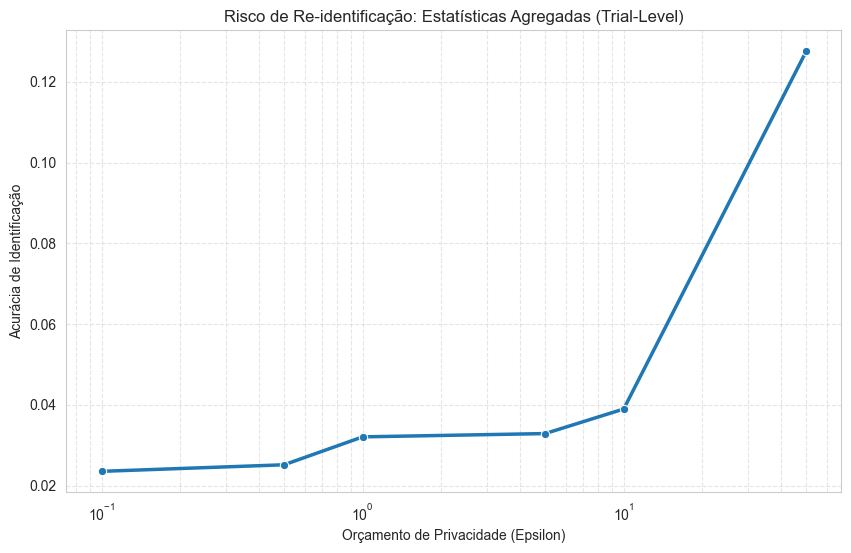

In [25]:
tag = "win1.00_step0.50_f5.0" # Match your tag


# --- 1. Carregar os Dados Agregados (Trials) ---
# Use o arquivo df_trials que você já gerou no notebook 03
# Ajuste o nome do arquivo conforme sua tag
trials_path = DATA_PROCESSED_DIR / "sisfall" / f"df_trials_{tag}.parquet"
df_trials = pd.read_parquet(trials_path)

# Filtrar apenas ADL (Caminhada/Corrida/Escada) para ser comparável com o experimento de Windows
# Se usarmos Falls aqui, o resultado será aleatório pois quedas não têm padrão de identidade.

target_activities = [
    'D01', 'D02', 'D03', 'D04', 'D05', 
    'D06', 'D07', 'D08', 'D09', 'D10', 
    'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17'
]

df_trials = df_trials[df_trials['activity_code'].isin(target_activities)].copy()

print(f"Total de Trials para Identificação: {len(df_trials)}")

# Definir as features agregadas (as que você usou no df_trials)
FEATURES_TRIAL = [
    "c2_max_max", "c2_max_mean", "c2_max_std",
    "c8_mean", "c8_max", "c9_mean", "c1_max_max"
]

# Target = Sujeito
le = LabelEncoder()
y = le.fit_transform(df_trials["subject_id"])
X = df_trials[FEATURES_TRIAL].to_numpy()

# --- 2. Função de Ruído DP (Reutilizável) ---
def apply_dp_noise(data, epsilon, sensitivity=2.0):
    """Adiciona ruído Laplace aos dados numpy"""
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale, size=data.shape)
    return data + noise

# --- 3. Loop de Experimento (Trial Level) ---
epsilons = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
results_trial = []

# StratifiedKFold garante que cada sujeito apareça no treino e teste
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Rodando Identificação por Nível de Trial...")

for eps in epsilons:
    fold_accs = []
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Clip e Ruído (Simulado)
        # Nota: Idealmente cliparíamos baseado nos quantis do treino
        q_low = np.quantile(X_train, 0.01, axis=0)
        q_high = np.quantile(X_train, 0.99, axis=0)
        
        X_train_cl = np.clip(X_train, q_low, q_high)
        X_test_cl = np.clip(X_test, q_low, q_high)
        
        X_train_dp = apply_dp_noise(X_train_cl, eps)
        X_test_dp = apply_dp_noise(X_test_cl, eps)
        
        # Modelo (Random Forest lida bem com dados tabulares pequenos)
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train_dp, y_train)
        
        preds = clf.predict(X_test_dp)
        fold_accs.append(accuracy_score(y_test, preds))
    
    avg_acc = np.mean(fold_accs)
    print(f"  Epsilon: {eps} -> Acurácia Média: {avg_acc:.2%}")
    results_trial.append({"Epsilon": eps, "Accuracy": avg_acc, "Type": "Trial-Level (Aggregated)"})

# --- 4. Plotar Comparativo (Se você tiver os dados do Window salvos) ---
# Adicione os dados do gráfico anterior (Window-Level) manualmente aqui ou combine os DFs
# Exemplo fictício dos seus dados de Window para plotar junto:
# window_data = [
#    {"Epsilon": 0.1, "Accuracy": 0.027, "Type": "Window-Level"},
#    {"Epsilon": 50.0, "Accuracy": 0.12, "Type": "Window-Level"},
#    ... etc
# ]
# df_plot = pd.concat([pd.DataFrame(results_trial), pd.DataFrame(window_data)])

# Plotando apenas o Trial-Level por enquanto:
df_plot = pd.DataFrame(results_trial)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x="Epsilon", y="Accuracy", marker="o", linewidth=2.5)
plt.xscale("log")
plt.title("Risco de Re-identificação: Estatísticas Agregadas (Trial-Level)")
plt.xlabel("Orçamento de Privacidade (Epsilon)")
plt.ylabel("Acurácia de Identificação")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [ ]:
# 1. LOAD DATA
data_path = DATA_PROCESSED_DIR / "sisfall" / f"windows_for_identification_{tag}.parquet"
df_windows = pd.read_parquet(data_path)

# Features from your extract function
FEATURES = ["c2_max", "c8", "c9", "c1_max"] 

In [ ]:
# 2. PREPARE TARGETS
# We are predicting 'subject_id', not 'label'
le = LabelEncoder()
y = le.fit_transform(df_windows["subject_id"]) # Converts 'SA01' -> 0, 'SA02' -> 1...
X = df_windows[FEATURES].to_numpy()

# Groups: We must group by the specific RECORDING (trial_id), not subject
# This ensures we train on Trial 1 & 2, and test on Trial 3
groups = df_windows["trial_id"].to_numpy() 

print(f"Classes: {len(le.classes_)}")
print(f"Features: {X.shape}")

Classes: 38
Features: (96174, 4)


In [28]:
# 3. DEFINE MODELS
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(solver='lbfgs', max_iter=2000))
    ]),
    "RandomForest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))
    ])
}

In [30]:
# 4. EVALUATION LOOP (Stratified K-Fold - Shuffle Split)
# Splits data into 5 folds with shuffling to verify data quality/signal.
sgkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    fold_accs = []
    
    # Nota: O argumento 'groups' é ignorado pelo StratifiedKFold, 
    # mas mantemos na chamada para compatibilidade se você trocar de volta depois.
    for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y)):
        # Split
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        preds = model.predict(X_test)
        
        # Score (Multi-class requires 'macro' or 'weighted' average for F1)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')
        
        fold_accs.append(acc)
        
        results.append({
            "Model": name,
            "Fold": fold,
            "Accuracy": acc,
            "F1_Macro": f1
        })
        
        # --- ALTERAÇÃO AQUI: Print do resultado do Fold atual ---
        print(f"  Fold {fold+1}: Accuracy = {acc:.2%} | F1 Macro = {f1:.4f}")
        
    print(f"  -> {name} Avg Accuracy: {np.mean(fold_accs):.2%}")


Training LogisticRegression...
  Fold 1: Accuracy = 7.76% | F1 Macro = 0.0479
  Fold 2: Accuracy = 7.64% | F1 Macro = 0.0457
  Fold 3: Accuracy = 7.58% | F1 Macro = 0.0483
  Fold 4: Accuracy = 7.54% | F1 Macro = 0.0474
  Fold 5: Accuracy = 7.86% | F1 Macro = 0.0487
  -> LogisticRegression Avg Accuracy: 7.68%

Training RandomForest...
  Fold 1: Accuracy = 41.52% | F1 Macro = 0.4149
  Fold 2: Accuracy = 41.01% | F1 Macro = 0.4085
  Fold 3: Accuracy = 40.96% | F1 Macro = 0.4088
  Fold 4: Accuracy = 41.41% | F1 Macro = 0.4137
  Fold 5: Accuracy = 40.76% | F1 Macro = 0.4069
  -> RandomForest Avg Accuracy: 41.13%


In [32]:
def add_dp_noise_to_windows(df, features, epsilon, sensitivity=1.0):
    """
    Applies Laplace noise to window-level features.
    Crucial: Data must be CLIPPED first for DP to be valid.
    """
    df_noisy = df.copy()
    
    # Calculate noise scale (b = sensitivity / epsilon)
    scale = sensitivity / epsilon
    
    for col in features:
        # 1. Clipping (Essential for DP)
        # We assume sensor stats shouldn't exceed reasonable bounds
        # e.g., C2 (acceleration) usually < 4g for ADL
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df_noisy[col] = df_noisy[col].clip(lower, upper)
        
        # 2. Add Noise
        noise = np.random.laplace(0, scale, size=len(df))
        df_noisy[col] += noise
        
    return df_noisy

In [ ]:
# --- Experiment Loop ---
epsilons = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
dp_results = []

for eps in epsilons:
    # Generate Noisy Data
    # Note: Sensitivity estimation is tricky. For normalized features, sens=1.
    # For raw features, it depends on clipping bounds. 
    # Here we assume a sensitivity relative to standard deviation range approx 1-2.
    df_noisy = add_dp_noise_to_windows(df_windows, FEATURES, epsilon=eps, sensitivity=2.0)
    
    X_noisy = df_noisy[FEATURES].to_numpy()
    
    # Quick eval using just one split to save time (or use full CV)
    train_idx, test_idx = next(sgkf.split(X_noisy, y))
    
    clf = models["RandomForest"] # RF usually handles unscaled data better
    clf.fit(X_noisy[train_idx], y[train_idx])
    acc = accuracy_score(y[test_idx], clf.predict(X_noisy[test_idx]))
    
    dp_results.append({"Epsilon": eps, "ID_Accuracy": acc})

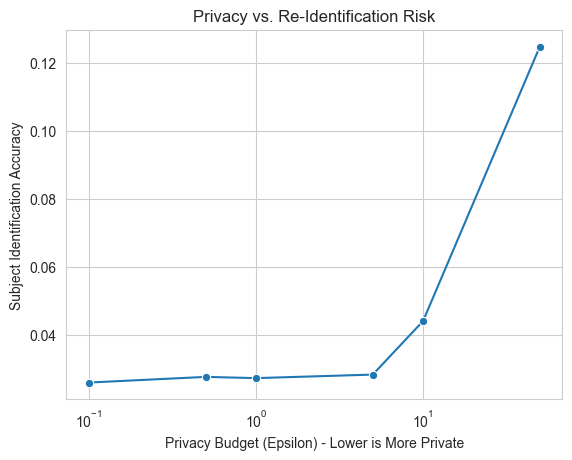

In [34]:
# Plot Trade-off
dp_df = pd.DataFrame(dp_results)
sns.lineplot(data=dp_df, x="Epsilon", y="ID_Accuracy", marker="o")
plt.xscale("log")
plt.title("Privacy vs. Re-Identification Risk")
plt.xlabel("Privacy Budget (Epsilon) - Lower is More Private")
plt.ylabel("Subject Identification Accuracy")
plt.grid(True)
plt.show()

In [ ]:
out_path = DATA_PROCESSED_DIR / "sisfall" / f"windows_ID_comprehensive_hybrid_{tag}.parquet"
df_windows_hybrid = pd.read_parquet(out_path)

In [6]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
# Filtrar colunas de features (excluir metadados)
metadata_cols = ['trial_id', 'label', 'subject_id', 'age_group', 'activity_code', 'sample_idx']
feature_cols = [c for c in df_windows_hybrid.columns if c not in metadata_cols]

print(f"Features usadas ({len(feature_cols)}): {feature_cols[:5]} ...")

# 2. PREPARAR ALVOS
# O alvo (y) é o SUJEITO
le = LabelEncoder()
y = le.fit_transform(df_windows_hybrid["subject_id"])
X = df_windows_hybrid[feature_cols].to_numpy()

# Grupos: Usamos o trial_id para garantir que janelas da mesma gravação
# fiquem juntas (ou todas no treino, ou todas no teste)
groups = df_windows_hybrid["trial_id"].to_numpy()

# 3. MODELAGEM (Baseline)
# RandomForest costuma ser excelente para biometria baseada em árvore
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# Validação Cruzada que respeita a estrutura dos dados
sgkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
print("Iniciando Validação Cruzada (Baseline)...")

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    scores.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.2%}")

print(f"\n>>> Acurácia Média da Baseline: {np.mean(scores):.2%} <<<")

Features usadas (70): ['ax_mean', 'ax_std', 'ax_max', 'ax_min', 'ax_iqr'] ...
Iniciando Validação Cruzada (Baseline)...
Fold 1 Accuracy: 86.49%
Fold 2 Accuracy: 85.28%
Fold 3 Accuracy: 85.50%
Fold 4 Accuracy: 86.25%
Fold 5 Accuracy: 85.46%

>>> Acurácia Média da Baseline: 85.79% <<<


In [12]:
mean_scores = np.mean(scores)

c:\Users\User\Documents\GitHub\aih-privacy\.venv\Lib\site-packages\sklearn\model_selection\_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(



Rodando Experimento de Privacidade...
Epsilon: 0.01 -> Acurácia de Re-identificação: 4.00%
Epsilon: 0.1 -> Acurácia de Re-identificação: 15.53%
Epsilon: 0.5 -> Acurácia de Re-identificação: 38.83%
Epsilon: 1.0 -> Acurácia de Re-identificação: 48.57%
Epsilon: 5.0 -> Acurácia de Re-identificação: 60.95%
Epsilon: 10.0 -> Acurácia de Re-identificação: 62.58%
Epsilon: 50.0 -> Acurácia de Re-identificação: 70.36%
Epsilon: 100.0 -> Acurácia de Re-identificação: 76.15%


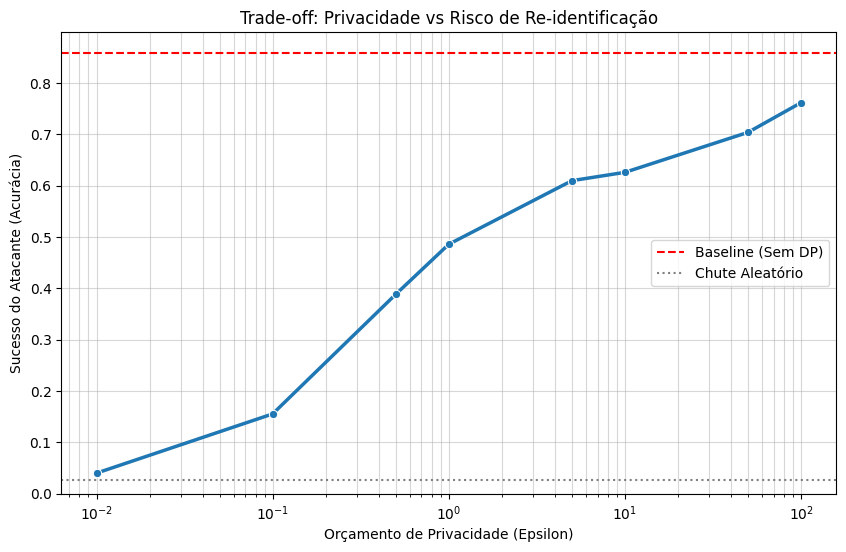

In [33]:
def apply_dp_noise(df, feature_cols, epsilon, sensitivity=1.0):
    """
    Aplica ruído de Laplace após 'clipar' os dados (obrigatório para DP).
    """
    df_noisy = df.copy()
    scale = sensitivity / epsilon
    
    for col in feature_cols:
        # 1. Clipping (Travar outliers para limitar a sensibilidade)
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df_noisy[col] = df_noisy[col].clip(lower, upper)
        
        # 2. Adicionar Ruído
        noise = np.random.laplace(0, scale, size=len(df))
        df_noisy[col] += noise
        
    return df_noisy

# --- Loop do Experimento ---
epsilons = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
dp_results = []

# Vamos usar apenas 1 split para ser mais rápido (ou use CV completo se tiver tempo)
train_idx, test_idx = next(sgkf.split(X, y, groups))
X_train_raw, y_train = X[train_idx], y[train_idx]
X_test_raw, y_test = X[test_idx], y[test_idx]

# Converter para DataFrame para facilitar o manuseio no noise function
df_train = pd.DataFrame(X_train_raw, columns=feature_cols)
df_test  = pd.DataFrame(X_test_raw, columns=feature_cols)

print("\nRodando Experimento de Privacidade...")

for eps in epsilons:
    # Aplicar DP no Treino e no Teste independentemente
    # (Sensitivity estimado como 2.0 considerando dados normalizados/estatísticos)
    df_train_noisy = apply_dp_noise(df_train, feature_cols, epsilon=eps, sensitivity=2.0)
    df_test_noisy  = apply_dp_noise(df_test, feature_cols, epsilon=eps, sensitivity=2.0)
    
    # Treinar no dado ruidoso
    model_dp = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
    model_dp.fit(df_train_noisy, y_train)
    
    # Testar (O atacante tenta identificar usando dados ruidosos)
    preds = model_dp.predict(df_test_noisy)
    acc = accuracy_score(y_test, preds)
    
    print(f"Epsilon: {eps} -> Acurácia de Re-identificação: {acc:.2%}")
    dp_results.append({"Epsilon": eps, "Accuracy": acc})

# --- Plotar o Gráfico Final ---
res_df = pd.DataFrame(dp_results)

plt.figure(figsize=(10, 6))
sns.lineplot(data=res_df, x="Epsilon", y="Accuracy", marker="o", linewidth=2.5)
plt.xscale("log")
plt.axhline(y=np.mean(scores), color='r', linestyle='--', label='Baseline (Sem DP)')
plt.axhline(y=1/len(le.classes_), color='gray', linestyle=':', label='Chute Aleatório')
plt.title("Trade-off: Privacidade vs Risco de Re-identificação")
plt.xlabel("Orçamento de Privacidade (Epsilon)")
plt.ylabel("Sucesso do Atacante (Acurácia)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Iniciando experimento com 10 níveis de privacidade...
Baseline esperada: ~85%
  Epsilon: 0.01  -> Acurácia: 4.14%
  Epsilon: 0.05  -> Acurácia: 8.99%
  Epsilon: 0.1   -> Acurácia: 15.27%
  Epsilon: 0.5   -> Acurácia: 39.08%
  Epsilon: 1.0   -> Acurácia: 47.70%
  Epsilon: 2.0   -> Acurácia: 54.46%
  Epsilon: 5.0   -> Acurácia: 59.41%
  Epsilon: 10.0  -> Acurácia: 62.84%
  Epsilon: 20.0  -> Acurácia: 67.19%
  Epsilon: 50.0  -> Acurácia: 71.20%


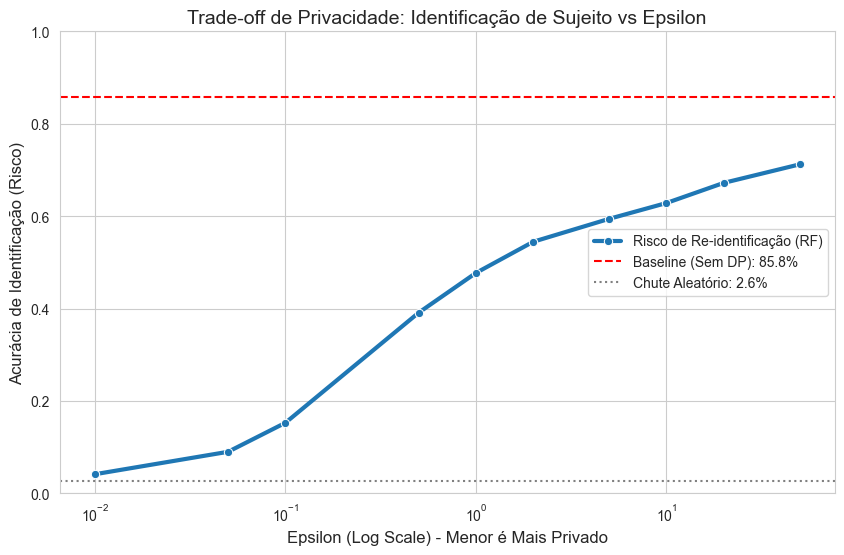

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- 1. Configuração e Dados ---
# (Assumindo que df e feature_cols já estão carregados do passo anterior)
X = df[feature_cols].to_numpy()
le = LabelEncoder()
y = le.fit_transform(df["subject_id"])

# Usamos o StratifiedKFold pois foi o que deu a melhor baseline (86%)
# Isso representa o "Risco Máximo de Re-identificação" que queremos mitigar.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pegamos apenas um split para o experimento de ruído (para ser rápido)
train_idx, test_idx = next(skf.split(X, y))
X_train_clean, y_train = X[train_idx], y[train_idx]
X_test_clean, y_test = X[test_idx], y[test_idx]

# Converter para DF para facilitar a aplicação do ruído
df_train_clean = pd.DataFrame(X_train_clean, columns=feature_cols)
df_test_clean = pd.DataFrame(X_test_clean, columns=feature_cols)

# --- 2. Função de Ruído (DP) ---
def apply_dp_noise(df_input, features, epsilon, sensitivity=2.0):
    """
    Aplica ruído Laplace.
    Nota: Em um cenário real de DP, o 'sensitivity' deve ser calculado rigorosamente
    baseado nos limites de clipagem. Aqui usamos uma estimativa para demonstração.
    """
    df_noisy = df_input.copy()
    
    # Escala do ruído (b = sensibilidade / epsilon)
    # Epsilon menor = Mais ruído = Mais privacidade
    scale = sensitivity / epsilon
    
    for col in features:
        # 1. Clipping (Obrigatório para limitar a sensibilidade)
        # Travamos os valores entre os percentis 1% e 99% para evitar outliers extremos
        lower = df_input[col].quantile(0.01)
        upper = df_input[col].quantile(0.99)
        
        # Clipamos o dado original antes de adicionar ruído
        data_clipped = df_noisy[col].clip(lower, upper)
        
        # 2. Gerar Ruído
        noise = np.random.laplace(0, scale, size=len(df_input))
        
        # 3. Somar
        df_noisy[col] = data_clipped + noise
        
    return df_noisy

# --- 3. Loop de Epsilons ---
# Lista de orçamentos de privacidade. 
# 0.01 = Privacidade Extrema (Dados destruídos)
# 100.0 = Quase sem privacidade (Dados originais)
epsilons = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

results = []

print(f"Iniciando experimento com {len(epsilons)} níveis de privacidade...")
print(f"Baseline esperada: ~85%")

for eps in epsilons:
    # A) Aplicar DP no Treino
    X_train_dp = apply_dp_noise(df_train_clean, feature_cols, epsilon=eps).to_numpy()
    
    # B) Aplicar DP no Teste 
    # (O cenário é: o atacante tem acesso a dados protegidos e tenta identificar)
    X_test_dp = apply_dp_noise(df_test_clean, feature_cols, epsilon=eps).to_numpy()
    
    # C) Treinar e Avaliar
    # Usamos menos árvores (50) para ser mais rápido, já que é uma simulação
    clf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
    clf.fit(X_train_dp, y_train)
    
    preds = clf.predict(X_test_dp)
    acc = accuracy_score(y_test, preds)
    
    print(f"  Epsilon: {eps:<5} -> Acurácia: {acc:.2%}")
    results.append({"Epsilon": eps, "Accuracy": acc})

# --- 4. Visualização Final ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Linha do experimento
sns.lineplot(data=pd.DataFrame(results), x="Epsilon", y="Accuracy", 
             marker="o", linewidth=3, label="Risco de Re-identificação (RF)")


random_guess = 1 / len(np.unique(y)) # ~2.6%

plt.axhline(y=mean_scores, color='r', linestyle='--', label=f'Baseline (Sem DP): {mean_scores:.1%}')
plt.axhline(y=random_guess, color='gray', linestyle=':', label=f'Chute Aleatório: {random_guess:.1%}')

plt.xscale("log") # Escala logarítmica é padrão para gráficos de Epsilon
plt.title("Trade-off de Privacidade: Identificação de Sujeito vs Epsilon", fontsize=14)
plt.xlabel("Epsilon (Log Scale) - Menor é Mais Privado", fontsize=12)
plt.ylabel("Acurácia de Identificação (Risco)", fontsize=12)
plt.legend()
plt.ylim(0, 1.0)
plt.show()

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

# Path Configuration
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.aih_privacy.config import DATA_PROCESSED_DIR

# Style Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# File Tag (Match the file names generated in previous steps)
TAG_FILE = "win3.00_step1.50_f20.0"

In [9]:
def add_dp_noise(df_input, features, epsilon, sensitivity=2.0):
    """
    Applies Laplace noise for Differential Privacy.
    Performs clipping (1% - 99%) before adding noise to bound sensitivity.
    """
    df_noisy = df_input.copy()
    
    # Calculate noise scale (b = sensitivity / epsilon)
    # Lower Epsilon = More Noise = More Privacy
    scale = sensitivity / epsilon
    
    for col in features:
        # 1. Clipping (Essential for valid DP)
        lower = df_input[col].quantile(0.01)
        upper = df_input[col].quantile(0.99)
        
        # Clip original data
        data_clipped = df_noisy[col].clip(lower, upper)
        
        # 2. Generate Laplace Noise
        noise = np.random.laplace(0, scale, size=len(df_input))
        
        # 3. Add Noise
        df_noisy[col] = data_clipped + noise
        
    return df_noisy

In [10]:
# --- 1. Load Window Data (Hybrid/V3) ---
# Ensure you point to the file generated with the V3 function
path_win_hybrid = DATA_PROCESSED_DIR / "sisfall" / f"windows_ID_comprehensive_hybrid_{TAG_FILE}.parquet"
df_win = pd.read_parquet(path_win_hybrid)

# Automatically identify feature columns (excluding metadata)
# This includes ax_mean, gy_kurt, mag_dom_freq, etc.
METADATA_COLS = ['trial_id', 'label', 'subject_id', 'age_group', 'activity_code', 'sample_idx']
FEATS_HYBRID = [c for c in df_win.columns if c not in METADATA_COLS]

print(f"[Window-Hybrid] Total Samples: {len(df_win)}")
print(f"[Window-Hybrid] Total Features: {len(FEATS_HYBRID)}")

# Prepare X and y
le_win = LabelEncoder()
y_win = le_win.fit_transform(df_win["subject_id"])
X_win_df = df_win[FEATS_HYBRID] # Keep as DataFrame for easy column noise injection

# --- 2. Prepare Split (Shuffle) ---
# We use StratifiedKFold (Shuffle) because we confirmed data quality is high (~86%)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx_win, test_idx_win = next(skf.split(X_win_df, y_win))

X_train_win = X_win_df.iloc[train_idx_win].reset_index(drop=True)
X_test_win  = X_win_df.iloc[test_idx_win].reset_index(drop=True)
y_train_win = y_win[train_idx_win]
y_test_win  = y_win[test_idx_win]

# Calculate Baseline (Clean Data)
print("Training Hybrid Baseline (No Noise)...")
clf_base = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
clf_base.fit(X_train_win, y_train_win)
acc_base_win = accuracy_score(y_test_win, clf_base.predict(X_test_win))
print(f"[Window-Hybrid] Baseline Accuracy: {acc_base_win:.2%}")

# --- 3. Privacy Loop (Window Hybrid) ---
epsilons = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
results_win = []

print("Starting noise injection on hybrid features...")

for eps in epsilons:
    # Apply DP (Sensitivity estimated at 2.0 for standardized/clipped sensor data)
    X_tr_noisy = add_dp_noise(X_train_win, FEATS_HYBRID, eps, sensitivity=2.0)
    X_te_noisy = add_dp_noise(X_test_win, FEATS_HYBRID, eps, sensitivity=2.0)
    
    # Train and Test
    clf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
    clf.fit(X_tr_noisy, y_train_win)
    preds = clf.predict(X_te_noisy)
    
    acc = accuracy_score(y_test_win, preds)
    
    results_win.append({
        "Epsilon": eps, 
        "Accuracy": acc, 
        "Scenario": "Window-Level (Hybrid Features)"
    })
    print(f"  [Window] Eps: {eps:<5} -> Acc: {acc:.2%}")

[Window-Hybrid] Total Samples: 25237
[Window-Hybrid] Total Features: 70
Training Hybrid Baseline (No Noise)...
[Window-Hybrid] Baseline Accuracy: 86.49%
Starting noise injection on hybrid features...
  [Window] Eps: 0.01  -> Acc: 4.42%
  [Window] Eps: 0.1   -> Acc: 15.89%
  [Window] Eps: 0.5   -> Acc: 39.12%
  [Window] Eps: 1.0   -> Acc: 47.33%
  [Window] Eps: 5.0   -> Acc: 59.61%
  [Window] Eps: 10.0  -> Acc: 63.77%
  [Window] Eps: 50.0  -> Acc: 72.21%


In [11]:
# --- 1. Load Aggregated Data (Trials) ---
# Note: Ensure you load the file generated in Notebook 03 (df_trials)
# The tag might be different if you generated it earlier (e.g., win1.00)
path_trial = DATA_PROCESSED_DIR / "sisfall" / f"df_trials_{TAG_FILE}.parquet" 
df_trial = pd.read_parquet(path_trial)

# Filter: Keep only ADL (Activities of Daily Living) to match the Window experiment
target_activities = [
    'D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 
    'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17'
]
df_trial = df_trial[df_trial['activity_code'].isin(target_activities)].copy()

# Features used for Fall Detection (Magnitude based)
FEATS_TRIAL = [
    "c2_max_max", "c2_max_mean", "c2_max_std",
    "c8_mean", "c8_max", "c9_mean", "c1_max_max"
]

print(f"[Trial] Total Samples: {len(df_trial)}")

# Prepare X and y
le_trial = LabelEncoder()
y_trial = le_trial.fit_transform(df_trial["subject_id"])
X_trial_df = df_trial[FEATS_TRIAL].reset_index(drop=True)

# --- 2. Prepare Split ---
# Use one split for consistency
train_idx_tr, test_idx_tr = next(skf.split(X_trial_df, y_trial))

X_train_trial = X_trial_df.iloc[train_idx_tr].reset_index(drop=True)
X_test_trial  = X_trial_df.iloc[test_idx_tr].reset_index(drop=True)
y_train_trial = y_trial[train_idx_tr]
y_test_trial  = y_trial[test_idx_tr]

# Calculate Baseline (Clean Data)
clf_base_tr = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
clf_base_tr.fit(X_train_trial, y_train_trial)
acc_base_trial = accuracy_score(y_test_trial, clf_base_tr.predict(X_test_trial))
print(f"[Trial] Baseline Accuracy: {acc_base_trial:.2%}")

# --- 3. Privacy Loop (Trials) ---
results_trial = []

for eps in epsilons:
    # Apply DP
    X_tr_noisy = add_dp_noise(X_train_trial, FEATS_TRIAL, eps, sensitivity=2.0)
    X_te_noisy = add_dp_noise(X_test_trial, FEATS_TRIAL, eps, sensitivity=2.0)
    
    # Train and Test
    clf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
    clf.fit(X_tr_noisy, y_train_trial)
    preds = clf.predict(X_te_noisy)
    
    acc = accuracy_score(y_test_trial, preds)
    
    results_trial.append({
        "Epsilon": eps, 
        "Accuracy": acc, 
        "Scenario": "Trial-Level (Aggregated)"
    })
    print(f"  [Trial] Eps: {eps:<5} -> Acc: {acc:.2%}")

[Trial] Total Samples: 2462
[Trial] Baseline Accuracy: 49.09%
  [Trial] Eps: 0.01  -> Acc: 2.43%
  [Trial] Eps: 0.1   -> Acc: 4.06%
  [Trial] Eps: 0.5   -> Acc: 1.83%
  [Trial] Eps: 1.0   -> Acc: 3.25%
  [Trial] Eps: 5.0   -> Acc: 2.03%
  [Trial] Eps: 10.0  -> Acc: 2.64%
  [Trial] Eps: 50.0  -> Acc: 13.18%


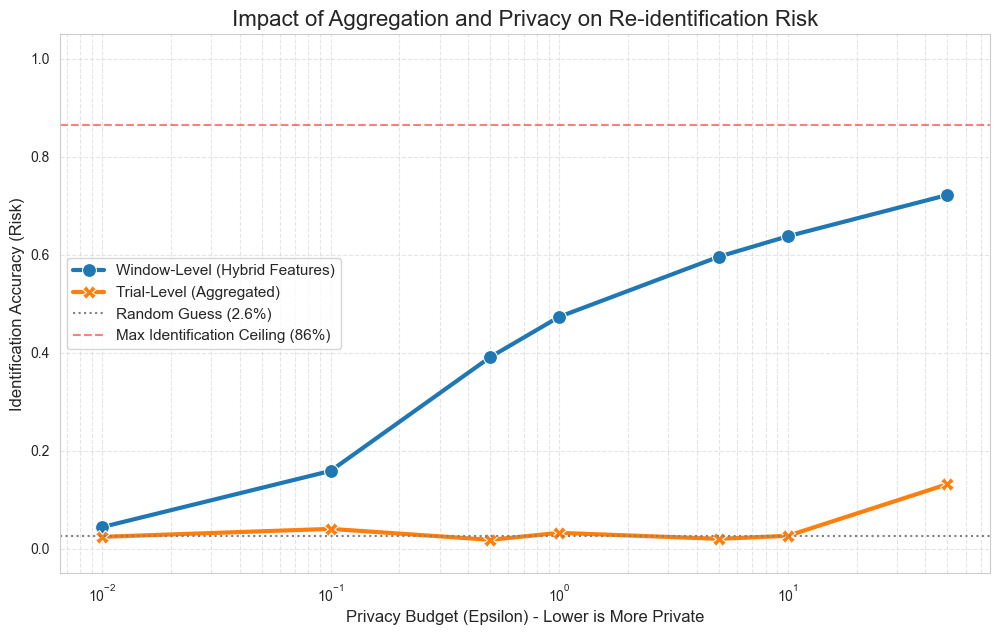

In [12]:
# Combine results
df_final_results = pd.concat([
    pd.DataFrame(results_win),   # Window Level (High Risk)
    pd.DataFrame(results_trial)  # Trial Level (Low Risk)
])

# Plot
plt.figure(figsize=(12, 7))

# Main plot
sns.lineplot(
    data=df_final_results, 
    x="Epsilon", 
    y="Accuracy", 
    hue="Scenario", 
    style="Scenario", 
    markers=True, 
    dashes=False,
    linewidth=3,
    markersize=10
)

# Reference Lines
random_guess = 1 / 38
plt.axhline(y=random_guess, color='gray', linestyle=':', label=f'Random Guess ({random_guess:.1%})')
plt.axhline(y=acc_base_win, color='red', linestyle='--', alpha=0.5, label=f'Max Identification Ceiling ({acc_base_win:.0%})')

# Styling
plt.xscale("log")
plt.title("Impact of Aggregation and Privacy on Re-identification Risk", fontsize=16)
plt.xlabel("Privacy Budget (Epsilon) - Lower is More Private", fontsize=12)
plt.ylabel("Identification Accuracy (Risk)", fontsize=12)
plt.ylim(-0.05, 1.05) # 0 to 100%
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

Analyzing Feature Importance on Window Dataset (Clean Data)...


C:\Users\User\AppData\Local\Temp\ipykernel_11752\1651080003.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='viridis')


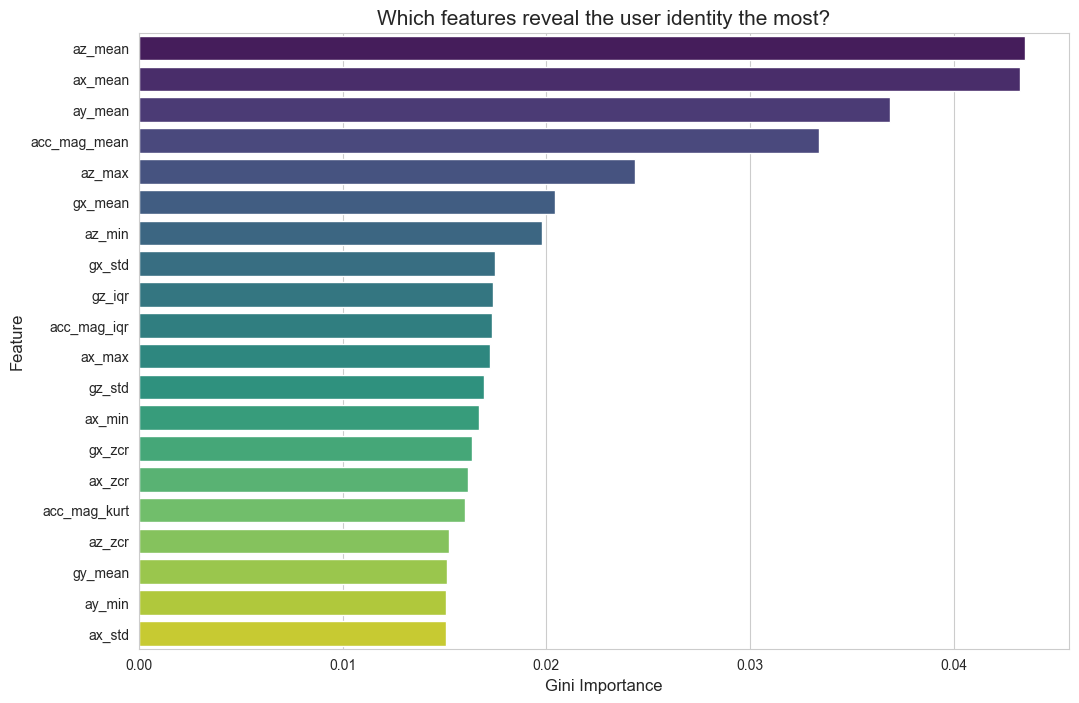

Top 10 Most Discriminative Features:
         Feature  Importance
16       az_mean    0.043490
0        ax_mean    0.043242
8        ay_mean    0.036859
48  acc_mag_mean    0.033373
18        az_max    0.024357
24       gx_mean    0.020423
19        az_min    0.019800
25        gx_std    0.017490
44        gz_iqr    0.017400
52   acc_mag_iqr    0.017328


In [13]:
# Train a final model on the clean Window data to extract importance
print("Analyzing Feature Importance on Window Dataset (Clean Data)...")

model_imp = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model_imp.fit(X_train_win, y_train_win)

# Extract Importances
importances = model_imp.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': FEATS_HYBRID,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualization (Top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='viridis')
plt.title('Which features reveal the user identity the most?', fontsize=15)
plt.xlabel('Gini Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

print("Top 10 Most Discriminative Features:")
print(feature_imp_df.head(10))